# LangGraph Basics

This notebook will walk you through the basics of LangGraph, with pauses for you to try out what you just learned and edit it.

## States and Nodes

LangGraph organizes workflows as graphs.
Nodes in the graph are functions.
Edges define execution flow.
All nodes share a common state that gets passed between them and updated as it flows through the graph.
This section shows how to define a state, create nodes, and connect them into an executable graph.

In [1]:
from IPython.display import Image, display
import operator
from typing import Annotated, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

We will start by defining the state.
This contains all of the info that our graph will pass through the process.

For our first state, we will keep it simple and store a list of strings.
States can be:
* `TypedDict` object
* dataclasses
* Pydantic `BaseModel` classes.

In [2]:
class State(TypedDict):
    nlist: list[str]

We will start with a very simple graph with only one node.
Remember that nodes are functions.
We add print statements so that we can see when/in what order our nodes execute.

In [3]:
def node_a(state: State) -> State:
    print(f"node a is receiving {state['nlist']}")
    note = "Hello World from Node a"
    return(State(nlist = [note]))


Now we are ready to build our graph.
We need to add edges, which will tell our graph in what order to execute our nodes.
This is a very simple graph, so we will follow the same path every time, but most graphs will have conditional edges or parallel edges (so that multiple functions execute at once).

Every LangGraph graph should start/end with reserved node names `START` and `END`, which we imported in the first code block.

In [4]:
builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_edge(START, "a")
builder.add_edge("a", END)
graph = builder.compile()

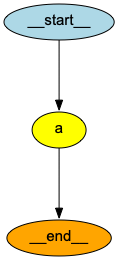

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))
# if draw mermaid times out, comment out the line above, and uncomment the following line
# display(Image(graph.get_graph().draw_png()))

Execute our graph with a sample state:

In [6]:
initial_state = State(
    nlist = ["Hello Node a, how are you?"]
)
graph.invoke(initial_state)

node a is receiving ['Hello Node a, how are you?']


{'nlist': ['Hello World from Node a']}

## Exercise 1:

Create a new node, node b, which will concatenate a message to `nlist` instead of overwriting it.
Create a new graph that executes node a and then node b.

### Summary:

Setup:

- State: All nodes share the same state which can be a Python TypedDict, dataclass, or a Pydantic BaseModel
- Nodes: Defined as simple Python functions that receive state as input and return updated state

Execution (invoke):

- Runtime: When you call invoke, the graph initializes the input state from your invoke statement and determines which nodes to run
- State Flow: Each node receives the current state as input, executes its logic, and returns an updated state
- Graph Return: After all nodes complete execution, the graph returns the final state value

## Edges

We just built a very simple graph, but we would like to be able to build more complicated graphs.
The first step will be parallel edges.
**Parallel edges** are when a node has multiple outgoing edges.


When we want to combine paths, we need a **reducer function**, which will tell our graph how to combine the information from multiple paths.
We will use `operator.concat` to accumulate info in our state as different functions execute, instead of just overwriting the state.

In [7]:
import operator
from typing import Annotated

Annotated typing lets us associate the operator with the list of strings.

In [8]:
class State(TypedDict):
    nlist: Annotated[list[str], operator.concat]

Define the nodes and build the graph:

In [13]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return(State(nlist = ["A"]))

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return(State(nlist = ["B"]))

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return(State(nlist = ["C"]))

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return(State(nlist = ["BB"]))

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return(State(nlist = ["CC"]))

def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['nlist']}")
    return(State(nlist = ["D"]))

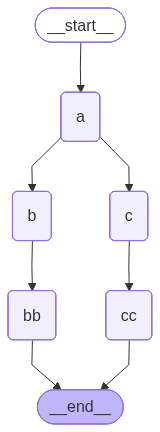

In [ ]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("bb", node_bb)
builder.add_node("cc", node_cc)
# builder.add_node("d", node_d)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "bb")
builder.add_edge("c", "cc")
builder.add_edge("bb", END)
builder.add_edge("cc", END)
# builder.add_edge("d",END)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
# if draw mermaid times out, comment out the line above, and uncomment the following line
# display(Image(graph.get_graph().draw_png()))

Invoke the graph and notice the order of execution, and the elements in `nlist` at each step.

In [15]:
initial_state = State(
    nlist = ["Initial String:"]
)
graph.invoke(initial_state)

Adding 'A' to ['Initial String:']
Adding 'B' to ['Initial String:', 'A']
Adding 'C' to ['Initial String:', 'A']
Adding 'BB' to ['Initial String:', 'A', 'B', 'C']
Adding 'CC' to ['Initial String:', 'A', 'B', 'C']


{'nlist': ['Initial String:', 'A', 'B', 'C', 'BB', 'CC']}

### Exercise 2:
* Try adding a third parallel path from node a.
* Instead of having all the paths join at d, have bb and cc pass to END. What values are merged?

### Summary:

Setup:

- State: You added a reducer function in the state definition using Annotated with `operator.add`
- Graph: You used `add_edge()` to create parallel paths from node 'a' to both 'b' and 'c'

Execution:

- Runtime: Nodes b and c operate in parallel, executing simultaneously
- The reducer function merges the values returned from parallel branches
- Results from node b and c are stored to state before starting node bb and cc

Result:

- The final result contains all values added to `nlist` by all nodes
- Values accumulate in the order nodes complete execution

## Conditional Edges

Conditional edges enable the state to be passed to different routes depending on the current state.

LangGraph has two main options for conditional edges:
* Use `Command` to return routing decisions from nodes.
* Use `add_conditional_edges` with a routing function.

Using `Command` is cleaner for simple use cases.
Using `add_conditional_edges` separates routing logic from node logic and encourages modular development.

### Option 1: Command

Type hints for the node output are not required but allow the graph to be rendered properly.

In [16]:
from langgraph.types import Command

In [17]:
def node_a(state: State) -> Command[Literal["b", "c", END]]:
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        next_node = END

    return Command(
        update = State(nlist = [select]),
        goto = [next_node]
    )

def node_b(state: State) -> State:
    return(State(nlist = ["B"]))
    
def node_c(state: State) -> State:
    return(State(nlist = ["C"]))



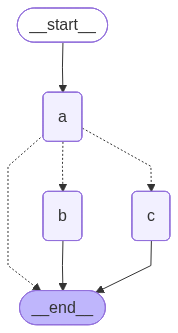

In [ ]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
# if draw mermaid times out, comment out the line above, and uncomment the following line
# display(Image(graph.get_graph().draw_png()))

In [19]:
user = input('b, c, or q to quit: ')

input_state = State(
    nlist = [user]
)
graph.invoke(input_state)

{'nlist': ['b', 'b', 'B']}

### Option 2: `add_conditional_edge`

The node switching logic that was part of node a, when node a returned a Command, is moved to the conditional edge function.
The conditional edge is manually added when the graph is built.

In [20]:
def node_a(state: State):
    return


def conditional_edge(state: State) -> Literal["b", "c", END]:
    select = state["nlist"][-1]
    if select == "b":
        return "b"
    elif select == "c":
        return "c"
    elif select == "q":
        return END
    else:
        return END

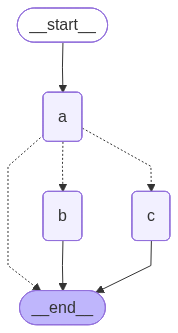

In [ ]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)
# now we add conditional edge manually
# because node a does not return a Command
builder.add_conditional_edges("a", conditional_edge)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
# if draw mermaid times out, comment out the line above, and uncomment the following line
# display(Image(graph.get_graph().draw_png()))



In [22]:
user = input('b, c, or q to quit: ')

input_state = State(
    nlist = [user]
)
graph.invoke(input_state)

{'nlist': ['c', 'C']}

In [23]:
while True:
    user = input('b, c, or q to quit: ')
    print(user)
    input_state = State(nlist =  [user])
    result = graph.invoke(input_state)
    print( result )
    if result['nlist'][-1] == "q":
        print("quit")
        break


b
{'nlist': ['b', 'B']}
c
{'nlist': ['c', 'C']}
b
{'nlist': ['b', 'B']}
c
{'nlist': ['c', 'C']}
q
{'nlist': ['q']}
quit


### Exercise 3

Try adding a new node 'd' and routing to it with a different input value.

### Summary:

Setup:

- Conditional Routing: Node a uses `Command` to return both state updates and routing decisions
- Alternative Approach: The conditional edge function separates routing logic from node logic

Execution:

- Based on user input, the graph routes to node 'b', 'c', or END
- The routing decision reads the last value in state to determine the next node
- Control flow changes based on state without hardcoded paths


## Memory

Memory allows graphs to store state information across multiple invocations.
This allows your agent to remember a conversation across multiple turns and accumulate results over time.

LangGraph builds in checkpointing utilities.
We will walk through `InMemorySaver`, the simplest framework for saving states.
Other options are SQLite and PostGres, along with other common database systems.

We can save different conversations separately using `thread_id`.


In [24]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

In [25]:
graph = builder.compile(checkpointer=memory)

In [26]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = State(nlist = [user])
    result = graph.invoke(input_state, config )
    print( result )
    if result['nlist'][-1] == "q":
        print("quit")
        break


{'nlist': ['b', 'B']}
{'nlist': ['b', 'B', 'c', 'C']}
{'nlist': ['b', 'B', 'c', 'C', 'b', 'B']}
{'nlist': ['b', 'B', 'c', 'C', 'b', 'B', 'b', 'B']}
{'nlist': ['b', 'B', 'c', 'C', 'b', 'B', 'b', 'B', 'b', 'B']}
{'nlist': ['b', 'B', 'c', 'C', 'b', 'B', 'b', 'B', 'b', 'B', 'q']}
quit


### Exercise 4

Change the `thread_id` to start a fresh conversation with an empty state.
Then return to the old `thread_id` to confirm that your old checkpoint still remembers the conversation.

### Summary

Setup:

- `InMemorySaver` and `thread_id` config enable state persistence across invocations
- Pass the checkpointer to `compile()` to enable memory

Execution:

- Each invoke with the same `thread_id` accesses the same persisted state
- State accumulates across multiple invocations within the same thread
- Different `thread_id`s maintain separate conversation histories


## Interrupts & Human in the Loop

Many applications will have human-in-the-loop stopping points.
The `interrupt()` function pauses graph execution and waits for input before continuing.
Interrupts require a checkpointer to save state across pauses.

In [27]:
from langgraph.types import interrupt

In [28]:
# overwrite memory so we start fresh
memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

In [29]:
# reconstruct graph
def node_a(state: State) -> Command[Literal["b", "c", END]]:
    print("Entered 'a' node")
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        admin = interrupt(f"Unexpected input '{select}'")
        print(admin)
        if admin == "continue":
            next_node = "b"
        else:
            next_node = END
            select = "q"
            
    return Command(
        update = State(nlist = [select]),
        goto = next_node
    )


def node_b (state: State) -> State:
    return(State(nlist = ["B"]))

def node_c (state: State) -> State:
    return(State(nlist = ["C"]))


In [30]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("b", END)
builder.add_edge("c", END)

# Compile
graph = builder.compile(checkpointer=memory)

In [31]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = State(nlist = [user])
    result = graph.invoke(input_state, config)

    if '__interrupt__' in result:
        print(f"Interrupt:{result}")
        msg = result['__interrupt__'][-1].value
        print(msg)
        human = input(f"\n{msg}: ")

        human_response = Command(
            resume = human
        )
        result = graph.invoke(human_response, config)
        
    if result['nlist'][-1] == "q":
        print("quit")
        break

Entered 'a' node
Entered 'a' node
Entered 'a' node
Entered 'a' node
Entered 'a' node
quit


### Exercise 5

* Modify the interrupt logic to ask different questions based on the unexpected input.
* Add interrupt calls in nodes b or c to pause at different points in the workflow.

### Summary
Setup:

- Node_a uses `interrupt()` to pause execution when unexpected input occurs
- Checkpointer enables interrupts by saving state between pause and resume

Execution:

- When interrupt is called, the graph pauses and waits for human input
- The admin response determines whether to continue execution or end
- Graph state is preserved during the pause and restored when resuming
- Everything before interrupt will re-run when resuming after interrupt, so recommend putting interrupt early in the node function.

<span style="color:gray">This tutorial is adapted from LangChain Academy's LangGraph Essentials course: https://github.com/langchain-ai/lca-langgraph-essentials.</span>
